<div style="text-align:center; font-size:50px; font-weight:700; margin-top:25px;">
Python pour Data Science - Projet - Groupe 4A
</div>

<div style="text-align:center; font-size:40px; font-weight:700; margin-top:25px;">
Prédiction des prix immobiliers
</div>

<br>

<div style="display:flex; justify-content:space-between; margin-top:35px; font-size:20px;">

  <div style="width:45%;">
    <div style="font-size:22px; font-weight:700; margin-bottom:10px;">Étudiants :</div>
    <div>• Yassine MELLOUL</div>
    <div>• Amira BARHOUMI</div>
    <div>• Antoine FOUCART</div>
  </div>

  <div style="width:45%; text-align:right;">
    <div style="font-size:22px; font-weight:700; margin-bottom:10px;">Chargé de TD :</div>
    <div>Julien PRAMIL</div>
  </div>

</div>

<br>
<hr>

# **1 - DESCRIPTION ET PROBLEMATIQUE**

Dans un contexte où les prix immobiliers sont fortement hétérogènes selon les territoires, le marché du logement en France présente de fortes disparités liées à la localisation, à 

l’attractivité des zones et aux dynamiques socio-économiques locales. Cette variabilité rend complexe la compréhension des mécanismes de formation des prix. Ainsi, la problématique 

centrale de ce projet est d’identifier et quantifier les facteurs influençant le prix de l’immobilier à l’échelle des communes. Nous nous concentrons en particulier sur des déterminants 

socio-économiques tels que la densité de population, le taux de chômage, le revenu moyen et le taux de pauvreté, afin d’évaluer leur impact sur les niveaux de prix. Pour cela, nous 

mobilisons deux sources de données principales : la base DVF (Demandes de Valeurs Foncières), qui recense les transactions immobilières en France , et les données socio-économiques de 

l’INSEE . Les jeux de données utilisés sont accessibles respectivement sur data.gouv.fr et insee.fr, via les liens suivants : 
https://www.data.gouv.fr/datasets/demandes-de-valeurs-foncieres et https://www.insee.fr/fr/statistiques/5359146 .

In [ ]:
# IMPORTATION
# modules
import pandas as pd
import numpy as np

# fonctions
from src.data.collect import load__data_url_zip_txt, load_insee_dossier_complet,load_logements_sociaux
from src.data.clean import filter_dvf_columns, compute_prix_m2, preprocess_insee, merge_all,handle_missing_values, remove_outliers
from src.data.stats_desc import univariate_numeric_analysis, carte_dep_communes_cartiflette, analyse_bivariée_quant_quant, carte_dep_communes_grid


#pour la modélisation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
from src.model.train import prepare_features, split_data, train_linear_regression, train_random_forest, train_gradient_boosting
from src.model.evaluate import evaluate_model, plot_feature_importance, plot_predictions, plot_residuals
#URL
URL_DVF = "https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20260405-002321/valeursfoncieres-2025.txt.zip"
URL_INSEE = "https://www.insee.fr/fr/statistiques/fichier/5359146/dossier_complet.zip"
URL_LOGEMENTS_SOCIAUX = "https://www.data.gouv.fr/api/1/datasets/r/b0d30277-3a14-4673-a988-2fa6c11e030c"





# **2 - COLLECTE DE DONNEES ET NETTOYAGE**

## **2-1 COLLECTE**

In [ ]:
# collecte de la base dvf
dvf = load__data_url_zip_txt(URL_DVF)

# aperçu des données brutes
summary_dvf = dvf.dtypes.to_frame(name="type")
summary_dvf["nb_valeurs_manquantes"] = dvf.isna().sum()

summary_dvf = summary_dvf.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = dvf.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_dvf)
print(dvf.head(2))

La base contient 3,7 millions de lignes et 43 colonnes. On observe que de nombreuses colonnes sont quasi entièrement vides (identifiants, lots, articles CGI). Les colonnes pertinentes pour notre étude sont le prix, la surface, le type de bien et la localisation. On conserve uniquement les ventes de maisons et d'appartements avec un prix et une surface strictement positifs, ce qui réduit la base à environ 1,1 million de transactions.

In [ ]:
# collecte de la base INSEE
insee = load_insee_dossier_complet(URL_INSEE)

# aperçu des données brutes
summary_insee = insee.dtypes.to_frame(name="type")
summary_insee["nb_valeurs_manquantes"] = insee.isna().sum()

summary_insee = summary_insee.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = insee.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_insee)
print(insee.head(5))

La base contient 34 988 communes et 7 variables. Le taux de pauvreté (TP6021) présente 30 591 valeurs manquantes sur 34 988 (87%), en raison du secret statistique appliqué aux communes de moins de 1 000 ménages. Cette variable est donc exclue de la modélisation. Le revenu médian (MED21) est au format texte avec des virgules comme séparateur décimal, il nécessite une conversion.

## **2-1 NETTOYAGE**

### **Base DVF**
Le nettoyage des données DVF vise à construire un jeu de données cohérent et exploitable pour la modélisation du prix immobilier.

Dans un premier temps, seules les variables pertinentes sont conservées : prix de transaction, localisation (code postal, commune, département, code commune), caractéristiques du bien (type de local, surface bâtie) et type de mutation. Les variables inutiles ou trop détaillées sont supprimées.

Ensuite, plusieurs transformations sont appliquées :
- conversion du prix en format numérique (suppression des espaces, gestion des virgules),
- harmonisation des types (variables qualitatives en `string`),
- standardisation des codes géographiques (zfill pour obtenir des codes à 2 et 5 chiffres).

Un filtrage est réalisé pour ne conserver que les observations pertinentes :
- uniquement les ventes,
- prix et surface strictement positifs,
- biens de type *Maison* ou *Appartement*.

Les valeurs manquantes sont supprimées afin d’assurer la qualité des données.

Enfin, une variable dérivée **prix au m²** est calculée comme le ratio entre la valeur foncière et la surface bâtie.

Ce processus permet d’obtenir un jeu de données propre, homogène et directement utilisable pour l’analyse et la modélisation.



In [ ]:
# Nettoyage
dvf = filter_dvf_columns(dvf)
# Ajout de la varible prix du metre carré
dvf = compute_prix_m2(dvf)
# aperçu des données tratées
summary_dvf_f = dvf.dtypes.to_frame(name="type")
summary_dvf_f["nb_valeurs_manquantes"] = dvf.isna().sum()

summary_dvf_f = summary_dvf_f.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = dvf.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_dvf_f)
print(dvf.head(5))

### **Base INSEE**
La fonction `preprocess_insee` a pour objectif de transformer un DataFrame INSEE brut en un jeu de données propre, standardisé et exploitable pour l’analyse statistique ou la modélisation.

Dans un premier temps, une copie du DataFrame est créée afin d’éviter toute modification directe des données d’origine. Cette étape garantit une approche non destructive du traitement.

Ensuite, les colonnes sont renommées pour améliorer leur lisibilité et leur cohérence. Les noms techniques issus de l’INSEE (comme `CODGEO`, `MED21` ou `TP6021`) sont remplacés par des appellations explicites telles que `code_commune`, `mediane_niveau_vie` ou `taux_pauvrete`. Cette standardisation facilite l’écriture du code et la compréhension des variables.

La fonction procède ensuite à la conversion des types de données. Le code commune et la médiane du niveau de vie sont convertis en type `string`, car ils correspondent à des identifiants ou des valeurs textuelles. Le taux de pauvreté subit un nettoyage plus avancé : les valeurs non exploitables comme `"s"` ou `"nd"` sont remplacées par des valeurs manquantes (`NaN`), les virgules sont converties en points pour respecter le format numérique, puis la variable est transformée en nombre et divisée par 100 afin d’obtenir un taux compris entre 0 et 1.

À partir des variables existantes, de nouveaux indicateurs sont créés. Le taux de chômage est calculé en rapportant le nombre de chômeurs de 15 à 64 ans à la population totale, ce qui fournit une mesure simple de la pression du chômage. La densité de population est également construite en divisant la population par la superficie, permettant d’évaluer le degré de concentration des habitants sur le territoire.

Enfin, toutes les lignes contenant des valeurs manquantes sont supprimées avec `dropna()`, afin d’obtenir un jeu de données entièrement complet et cohérent pour les analyses futures.

In [ ]:
# Nettoyage
insee = preprocess_insee(insee)

# aperçu des données traitées
summary_insee_f = insee.dtypes.to_frame(name="type")
summary_insee_f["nb_valeurs_manquantes"] = insee.isna().sum()

summary_insee_f = summary_insee_f.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = insee.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_insee_f)
print(insee.head(5))

### **Fusion des jeux de données selon code commune**

In [ ]:
# merge
log_soc=load_logements_sociaux(URL_LOGEMENTS_SOCIAUX)
data_final = merge_all(dvf, insee,log_soc)
# aperçu
print(data_final.head(6))
print(data_final.shape)

# **3 - ANALYSE DESCRIPTIVE**

## **3-1 - Univarié**

### **Valeur foncière**

In [ ]:
stats = univariate_numeric_analysis(data_final,"valeur_fonciere" )

### **prix du mètre carré**

In [ ]:
stats2 = univariate_numeric_analysis(data_final,"prix_m2" )

In [ ]:

statsq = univariate_numeric_analysis(data_final,"prix_m2" )
data_final = handle_missing_values(data_final) 
data_final = remove_outliers(data_final, ["prix_m2", "surface_reelle_bati", "valeur_fonciere","densite"])

### **densité de population**

In [ ]:
stats3 = univariate_numeric_analysis(data_final,"densite" )

### **Superficie de communes**

In [ ]:
stats4 = univariate_numeric_analysis(data_final,"superficie" )

## **3-2 - Bivarié**

In [ ]:
analyse_bivariée_quant_quant(data_final,["prix_m2", "densite", "taux_chomage", "mediane_niveau_vie"])

In [ ]:
carte_dep_communes_cartiflette(
    df=data_final,
    col="taux_chomage",
    code_dep=75
)

# **4 - MODÉLISATION**

L'objectif est de prédire le **prix au m²** des biens immobiliers à partir des caractéristiques du bien (DVF) et du contexte socio-économique de la commune (INSEE). Nous comparons trois modèles : une régression linéaire (baseline), un Random Forest et un Gradient Boosting.

### 4.1 - Préparation des données

Nous retenons 7 variables explicatives issues de trois sources. La surface bâtie et le nombre de pièces caractérisent le bien, le type de local distingue maisons et appartements. Côté INSEE, la médiane du niveau de vie et le taux de chômage captent le contexte économique, la densité capte l'effet urbain/rural. Le taux de logements sociaux (data.gouv.fr) caractérise la structure du parc immobilier. Les données sont séparées en 80% entraînement et 20% test (random_state=42 pour la reproductibilité).

In [52]:
X, y = prepare_features(data_final)
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")
X.dropna()

Train : 580734 lignes
Test  : 145184 lignes


,surface_reelle_bati,nombre_pieces_principales,mediane_niveau_vie,taux_chomage,taux_logements_sociaux,densite,type_local_Maison
0,111.0,5.0,37990.0,0.079117,5.0,74.579832,True
1,87.0,4.0,30110.0,0.063225,3.0,25.401460,False
4,35.0,2.0,35280.0,0.114649,20.0,420.206121,False
5,95.0,2.0,25520.0,0.040227,2.0,69.360269,True
6,49.0,2.0,24610.0,0.063358,14.0,120.414573,False
...,...,...,...,...,...,...,...
1111205,25.0,1.0,41550.0,0.093065,0.0,9757.666463,False
1111208,40.0,1.0,41550.0,0.093065,0.0,9757.666463,False
1111211,77.0,3.0,29940.0,0.092216,0.0,8565.441176,False
1111221,39.0,2.0,29940.0,0.092216,0.0,8565.441176,False


### 4.2 - Régression linéaire (baseline)

La régression linéaire suppose une relation proportionnelle entre chaque variable et le prix au m². C'est un modèle simple et interprétable grâce à ses coefficients. Il sert de référence .

In [57]:
reg = train_linear_regression(X_train, y_train)
y_pred_reg = reg.predict(X_test)

res_reg = evaluate_model(y_test, y_pred_reg, "Régression Linéaire")
 

# Coefficients
coefs = pd.DataFrame({
    "variable": X.columns,
    "coefficient": reg.coef_
}).sort_values("coefficient", ascending=False)
coefs


=== Régression Linéaire ===
MAE  : 1087.18 €/m²
RMSE : 1604.15 €/m²
R²   : 0.2828


,variable,coefficient
3,taux_chomage,4384.450108
6,type_local_Maison,5.385081
2,mediane_niveau_vie,0.179380
5,densite,0.120865
4,taux_logements_sociaux,-4.782552
0,surface_reelle_bati,-19.372912
1,nombre_pieces_principales,-141.834771


**Interprétation des coefficients :** un coefficient positif pour la médiane du niveau de vie signifie qu'une commune plus riche est associée à un prix au m² plus élevé. À l'inverse, le coefficient négatif de la surface confirme l'effet de dégressivité classique en immobilier : plus un bien est grand, moins le prix au m² est élevé. Le R² faible (≈0.28) montre que la relation entre les prix et les variables n'est pas linéaire.

### 4.3 - Random Forest

Le Random Forest est un ensemble de 100 arbres de décision qui votent ensemble pour la prédiction finale. Contrairement à la régression linéaire, il capture les **relations non-linéaires** et les **interactions entre variables** (par exemple : grande surface dans une commune riche ≠ grande surface dans une commune pauvre).

In [58]:
rf = train_random_forest(X_train, y_train)
y_pred_rf = rf.predict(X_test)
 
res_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")


=== Random Forest ===
MAE  : 788.30 €/m²
RMSE : 1302.27 €/m²
R²   : 0.5273


### 4.4 - Gradient Boosting

Le Gradient Boosting construit les arbres **séquentiellement** : chaque nouvel arbre corrige les erreurs du précédent. C'est souvent le modèle le plus performant sur des données tabulaires.

In [ ]:
gb = train_gradient_boosting(X_train, y_train)
y_pred_gb = gb.predict(X_test)
 
res_gb = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
 

### 4.5 - Comparaison des modèles

Trois métriques sont utilisées :
- **MAE** : erreur moyenne absolue en €/m², la plus intuitive
- **RMSE** : pénalise davantage les grosses erreurs, pertinent en immobilier
- **R²** : part de variance expliquée (1 = parfait, 0 = inutile) ( un R² de 0.53 signifie que 53% des différences de prix entre les biens sont captées par nos variables.)

In [ ]:
resultats = pd.DataFrame([res_reg, res_rf, res_gb])
resultats

### 4.6 - Importance des variables

Le Random Forest permet d'identifier les variables qui contribuent le plus à la prédiction du prix au m².

In [ ]:
plot_feature_importance(rf, X.columns)

### 4.7 - Prédictions vs réalité
Ce graphique compare les prix prédits aux prix réels. Plus les points sont proches de la diagonale rouge (prédiction = réalité), meilleur est le modèle. On observe que le Random Forest concentre davantage ses prédictions autour de la diagonale, confirmant sa supériorité.

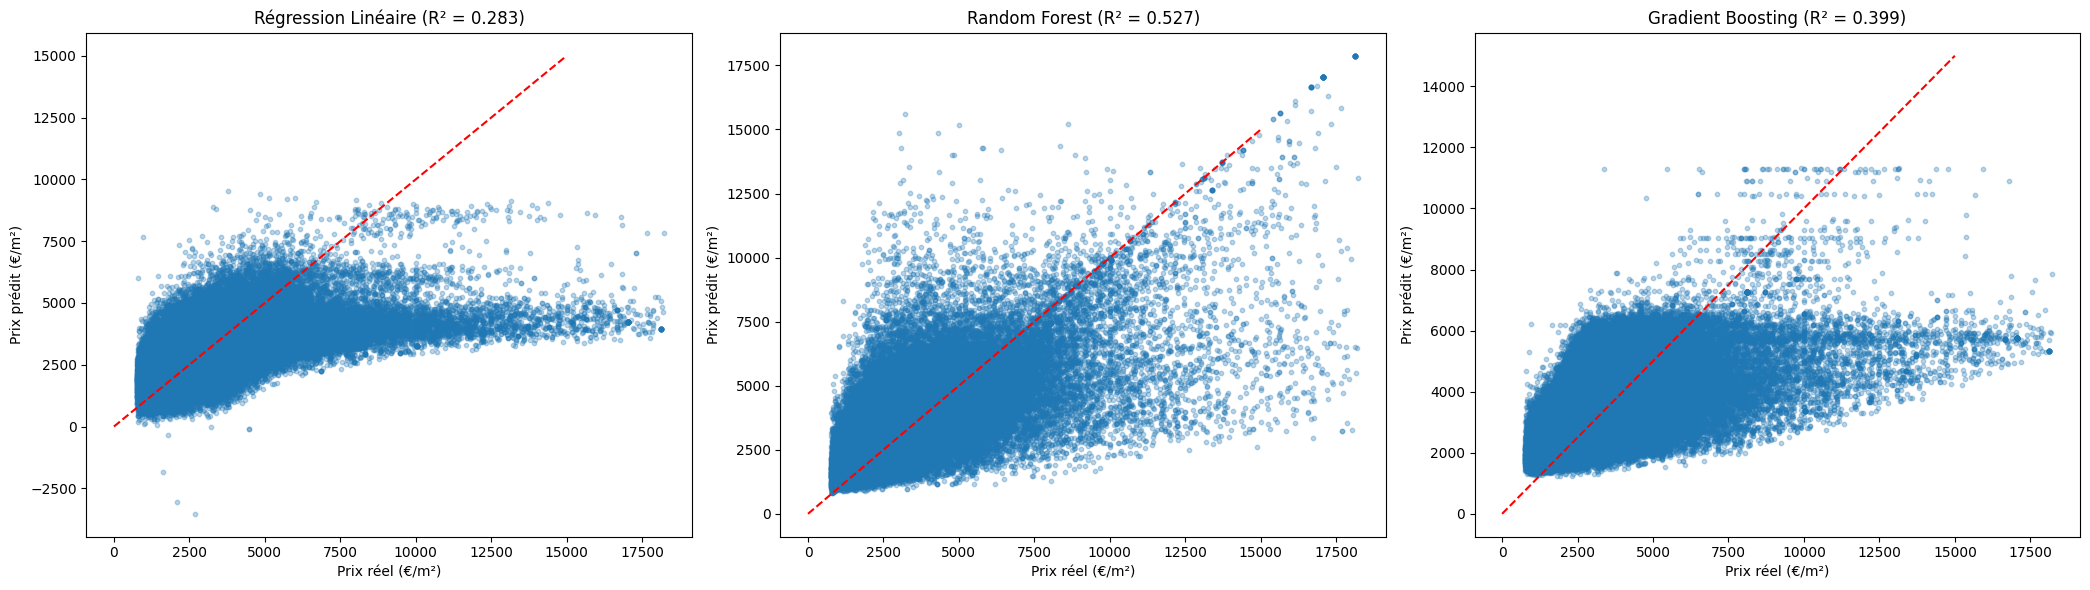

In [55]:
plot_predictions(
    y_test,
    [y_pred_reg, y_pred_rf, y_pred_gb],
    ["Régression Linéaire", "Random Forest", "Gradient Boosting"]
)

### 4.9 - Analyse des résidus

La distribution des résidus (erreur = prix réel - prix prédit) permet de vérifier si le modèle a un biais systématique. Si la distribution est centrée autour de 0, le modèle ne sur-estime ni ne sous-estime les prix de manière systématique.
 

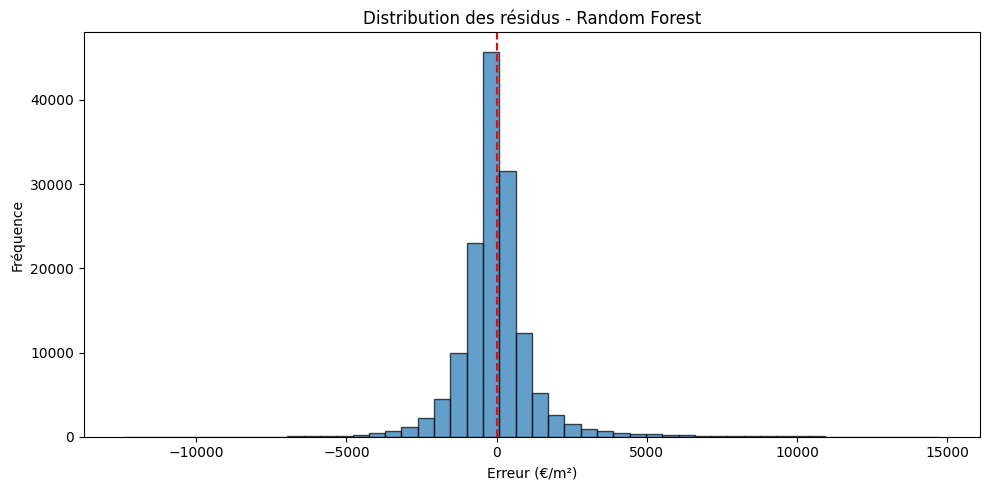

In [53]:

plot_residuals(y_test, y_pred_rf, "Random Forest")

La distribution est centrée autour de 0 (ligne rouge), ce qui confirme l'absence de biais systématique : le modèle ne sur-estime ni ne sous-estime les prix de manière globale. On observe cependant une **asymétrie vers la droite** (queue longue entre 5 000 et 15 000 €/m²) : le modèle sous-estime certains biens chers.


### 4.8 - Tentative d'amélioration : log-transformation

Le prix au m² ayant une distribution asymétrique, nous avons testé une log-transformation : entraîner le modèle sur log(prix) puis retransformer les prédictions. Cette technique permet souvent de mieux capter les variations relatives des prix. Résultat : R² ≈ 0.53, aucun gain par rapport au Random Forest standard. Cela suggère que le plafond de performance est lié aux variables disponibles et non à la méthode de modélisation.

In [ ]:

# Entraîner sur le log du prix
y_train_log = np.log1p(y_train)

rf_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_log.fit(X_train, y_train_log)

# Prédire et retransformer
y_pred_log = rf_log.predict(X_test)
y_pred_rf_log = np.expm1(y_pred_log)

# Évaluer sur les vrais prix
mae = mean_absolute_error(y_test, y_pred_rf_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_log))
r2 = r2_score(y_test, y_pred_rf_log)

print(f"=== Random Forest (log) ===")
print(f"MAE  : {mae:.2f} €/m²")
print(f"RMSE : {rmse:.2f} €/m²")
print(f"R²   : {r2:.4f}")

### 4.9 - Analyse par département

Pour comprendre les limites du modèle national, nous testons le Random Forest sur plusieurs départements individuellement.

In [54]:

for dep in ["35", "69", "33", "59", "13"]:
    df_dep = data_final[data_final["code_departement"] == dep]
    if len(df_dep) > 5000:
        X_dep, y_dep = prepare_features(df_dep)
        X_train_d, X_test_d, y_train_d, y_test_d = split_data(X_dep, y_dep)
        
        rf_dep = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_dep.fit(X_train_d, y_train_d)
        y_pred_d = rf_dep.predict(X_test_d)
        
        print(f"Département {dep} : {len(df_dep)} lignes | R² = {r2_score(y_test_d, y_pred_d):.4f}")

Département 35 : 14564 lignes | R² = 0.5842
Département 69 : 15574 lignes | R² = 0.4264
Département 33 : 26588 lignes | R² = 0.5630
Département 59 : 31086 lignes | R² = 0.4798
Département 13 : 20790 lignes | R² = 0.2514


Les performances varient fortement selon le département. Le modèle fonctionne mieux dans des départements au marché diversifié comme l'Ille-et-Vilaine (R² ≈ 0.58) ou la Gironde (R² ≈ 0.56) que dans les départements dominés par une grande métropole comme les Bouches-du-Rhône (R² ≈ 0.25), où les disparités entre quartiers au sein d'une même commune ne sont pas captées par nos variables communales.

### 4.10 - Limites et perspectives

Notre meilleur modèle (Random Forest) explique environ 53% de la variance des prix au m², avec une erreur moyenne de 788 €/m². Nous avons également testé un XGBoost qui n'a pas surpassé le Random Forest sur nos données (R² ≈ 0.47).

Les 47% restants s'expliquent par des caractéristiques absentes de nos données :

- **L'étage** : un appartement au dernier étage avec vue ne vaut pas le même prix qu'un rez-de-chaussée sur cour
- **L'état du bien** : un logement neuf et un logement à rénover de même surface dans la même commune auront des prix très différents
- **La micro-localisation** : nos variables INSEE sont agrégées au niveau communal, or au sein d'une même ville les prix varient fortement d'un quartier à l'autre, comme le montre l'analyse par département (section 4.8)
- **La proximité des transports et commerces** : facteur majeur du prix en zone urbaine, non disponible dans nos sources

Le taux de pauvreté a dû être exclu de la modélisation en raison de 87% de valeurs manquantes, liées au secret statistique appliqué par l'INSEE aux communes de moins de 1 000 ménages.

**Pistes d'amélioration :**
- Utiliser les données INSEE au niveau **IRIS** (infra-communal) pour capter les disparités au sein des communes
- Intégrer les **coordonnées géographiques** (latitude/longitude) des biens pour capter la micro-localisation
- Enrichir avec des données complémentaires : proximité gares, scores d'accessibilité, données cadastrales sur l'ancienneté du bâti